In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV dosyasını oku
df = pd.read_csv('../../data/amzn_stock.csv')

print("Veri boyutu:", df.shape)
print("\nSütunlar:", df.columns.tolist())
df.head()

Veri boyutu: (3019, 7)

Sütunlar: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Name']


,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


In [1]:
print("test")

test


In [ ]:
import pandas as pd
print("pandas OK:", pd.__version__)

In [4]:
import os
print(os.listdir('../../data'))

['amzn_stock.csv']


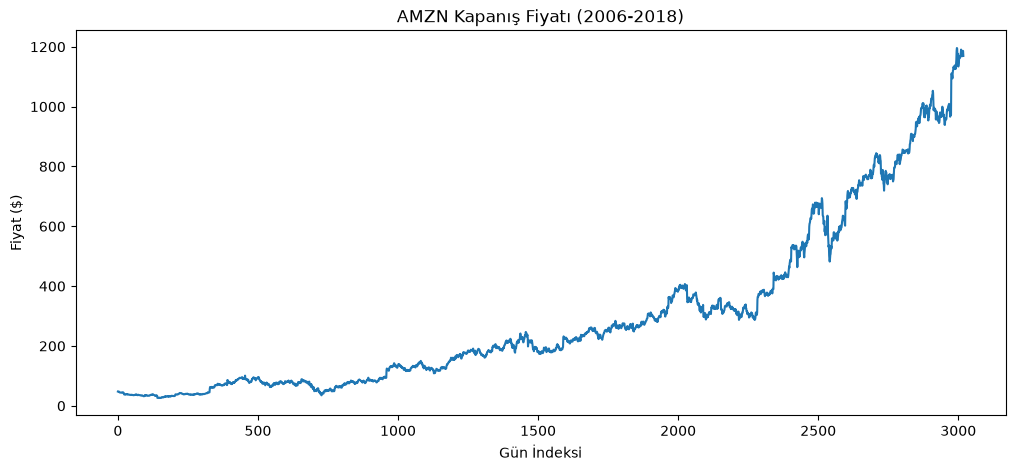

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df['Close'])
plt.title('AMZN Kapanış Fiyatı (2006-2018)')
plt.xlabel('Gün İndeksi')
plt.ylabel('Fiyat ($)')
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Sadece kapanış fiyatını al, 2D array'e çevir (scaler bunu bekler)
close_prices = df['Close'].values.reshape(-1, 1)

# Fiyatları -1 ile 1 arasına ölçekle
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

print("Orijinal ilk 5 değer:", close_prices[:5].flatten())
print("Ölçeklenmiş ilk 5 değer:", scaled_prices[:5].flatten())

Orijinal ilk 5 değer: [47.58 47.25 47.65 47.87 47.08]
Ölçeklenmiş ilk 5 değer: [-0.96322323 -0.96378744 -0.96310354 -0.9627274  -0.9640781 ]


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Sadece kapanış fiyatını al, 2D array'e çevir (scaler bunu bekler)
close_prices = df['Close'].values.reshape(-1, 1)

# Fiyatları -1 ile 1 arasına ölçekle
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

print("Orijinal ilk 5 değer:", close_prices[:5].flatten())
print("Ölçeklenmiş ilk 5 değer:", scaled_prices[:5].flatten())

Orijinal ilk 5 değer: [47.58 47.25 47.65 47.87 47.08]
Ölçeklenmiş ilk 5 değer: [-0.96322323 -0.96378744 -0.96310354 -0.9627274  -0.9640781 ]


In [9]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])      # geçmiş `lookback` gün
        y.append(data[i+lookback])         # bir sonraki gün (hedef)
    return np.array(X), np.array(y)

lookback = 20  # geçmiş 20 güne bakarak 21. günü tahmin edeceğiz

X, y = create_sequences(scaled_prices, lookback)

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (2999, 20, 1)
y boyutu: (2999, 1)


In [10]:
# Zaman serisinde rastgele karıştırma YAPMIYORUZ — sırayı koruyoruz!
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Eğitim seti:", X_train.shape, y_train.shape)
print("Test seti:", X_test.shape, y_test.shape)

# NumPy array'lerini PyTorch tensörlerine çevir
import torch

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print("\nTensor tipleri:", type(X_train), X_train.dtype)

Eğitim seti: (2399, 20, 1) (2399, 1)
Test seti: (600, 20, 1) (600, 1)

Tensor tipleri: <class 'torch.Tensor'> torch.float32


# Hafta 4: Veri Hazırlığı

**Not:** Bu projede Python 3.14 ile Jupyter kernel çökme sorunu yaşandı 
(muhtemelen ipykernel'in bu kadar yeni bir Python sürümüyle tam uyumlu 
olmaması). Çözüm: Python 3.13'e geçilip venv yeniden oluşturuldu.